<a href="https://colab.research.google.com/github/zeno2301/LLM/blob/main/laba4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Лаба4

Практика: Работаем с тем же набором данных, что и в прошлый раз (про диабет у индейцев Пима).
Нужно обучить три разные модели:

1. Обычную логистическую регрессию (как базу).

2. Модель на основе бэггинга (используем BaggingClassifier).

3. Модель градиентного бустинга (используем GradientBoostingClassifier).

Настройка: В каждой модели обязательно нужно покрутить гиперпараметры, а не просто запускать «как есть». Нужно посмотреть, как меняется результат от изменения настроек.

Как оцениваем?
Для каждого метода считаем три метрики:

- Recall (она же чувствительность).
- F1-меру.
- Специфичность (её в готовых библиотеках нет, так что считаем сами по формуле через матрицу ошибок).

In [14]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import BaggingClassifier, GradientBoostingClassifier
from sklearn.metrics import recall_score, f1_score, confusion_matrix

# Загрузка набора данных (предполагается, что 'diabetes.csv' находится в /content/)
data_file_path = '/content/diabetes.csv'
df = pd.read_csv(data_file_path)

# Разделение на признаки (X) и целевую переменную (y)
# Признаки были определены на предыдущих шагах: 'Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age'
features = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']
target = 'Outcome'

X = df[features]
y = df[target]

# Разделение данных на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Масштабирование признаков (важно для логистической регрессии и может быть полезно для других моделей)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Подготовка данных завершена. Созданы и масштабированы обучающая и тестовая выборки.")

Подготовка данных завершена. Созданы и масштабированы обучающая и тестовая выборки.


Now, let's define a function to calculate the required metrics: Recall, F1-score, and Specificity. Specificity is calculated manually from the confusion matrix.

In [15]:
def evaluate_model_metrics(y_true, y_pred, model_name="Model"):
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    cm = confusion_matrix(y_true, y_pred)

    # Расчет специфичности
    # Специфичность = Истинно отрицательные / (Истинно отрицательные + Ложноположительные)
    # cm[0,0] = Истинно отрицательные, cm[0,1] = Ложноположительные
    tn, fp, fn, tp = cm.ravel()

    specificity = tn / (tn + fp) if (tn + fp) != 0 else 0

    print(f"--- {model_name} Metrics ---")
    print(f"Полнота (Чувствительность): {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print(f"Специфичность: {specificity:.4f}")
    print("\nConfusion Matrix:")
    print(cm)
    print("----------------------")

    return {'recall': recall, 'f1_score': f1, 'specificity': specificity}

### 1. Обычная логистическая регрессия (как база)

In [16]:
# Инициализация и обучение логистической регрессии
# Логистическая регрессия очень чувствительна к масштабу признаков, поэтому используем масштабированные данные.
log_reg = LogisticRegression(solver='liblinear', random_state=42)

# Определение сетки гиперпараметров для GridSearchCV
# 'C' - это обратная сила регуляризации. Меньшие значения означают более сильную регуляризацию.
param_grid_lr = {
    'C': [0.01, 0.1, 1, 10, 100, 1000]
}

# Настройка GridSearchCV для логистической регрессии
# cv=5 означает 5-кратную перекрестную проверку
# scoring='f1' для оптимизации F1-меры
grid_search_lr = GridSearchCV(log_reg, param_grid_lr, cv=5, scoring='f1', n_jobs=-1)
grid_search_lr.fit(X_train_scaled, y_train)

print(f"Лучшие гиперпараметры для Логистической регрессии: {grid_search_lr.best_params_}")

# Получение лучшей модели
best_log_reg = grid_search_lr.best_estimator_

# Прогнозирование на тестовом наборе данных
y_pred_log_reg = best_log_reg.predict(X_test_scaled)

# Оценка метрик
metrics_log_reg = evaluate_model_metrics(y_test, y_pred_log_reg, model_name="Логистическая регрессия (с тюнингом)")

Лучшие гиперпараметры для Логистической регрессии: {'C': 1}
--- Логистическая регрессия (с тюнингом) Metrics ---
Полнота (Чувствительность): 0.5185
F1-Score: 0.5874
Специфичность: 0.8667

Confusion Matrix:
[[130  20]
 [ 39  42]]
----------------------


### 2. Модель на основе бэггинга (BaggingClassifier)

In [17]:
bag_clf = BaggingClassifier(random_state=42, n_jobs=-1)

# Определение сетки гиперпараметров для BaggingClassifier
param_grid_bag = {
    'n_estimators': [10, 50, 100, 200],
    'max_features': [0.5, 0.7, 1.0] # Процент признаков для каждого базового оценщика
}

# Настройка GridSearchCV для BaggingClassifier
grid_search_bag = GridSearchCV(bag_clf, param_grid_bag, cv=5, scoring='f1', n_jobs=-1)
grid_search_bag.fit(X_train_scaled, y_train)

print(f"Лучшие гиперпараметры для BaggingClassifier: {grid_search_bag.best_params_}")

# Получение лучшей модели
best_bag_clf = grid_search_bag.best_estimator_

# Прогнозирование на тестовом наборе данных
y_pred_bag_clf = best_bag_clf.predict(X_test_scaled)

# Оценка метрик
metrics_bag_clf = evaluate_model_metrics(y_test, y_pred_bag_clf, model_name="BaggingClassifier (с тюнингом)")

Лучшие гиперпараметры для BaggingClassifier: {'max_features': 1.0, 'n_estimators': 200}
--- BaggingClassifier (с тюнингом) Metrics ---
Полнота (Чувствительность): 0.5432
F1-Score: 0.6069
Специфичность: 0.8667

Confusion Matrix:
[[130  20]
 [ 37  44]]
----------------------


### 3. Модель градиентного бустинга (GradientBoostingClassifier)

In [18]:
grad_boost = GradientBoostingClassifier(random_state=42)

# Определение сетки гиперпараметров для GradientBoostingClassifier
param_grid_grad = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7]
}

# Настройка GridSearchCV для GradientBoostingClassifier
grid_search_grad = GridSearchCV(grad_boost, param_grid_grad, cv=5, scoring='f1', n_jobs=-1)
grid_search_grad.fit(X_train_scaled, y_train)

print(f"Лучшие гиперпараметры для GradientBoostingClassifier: {grid_search_grad.best_params_}")

# Получение лучшей модели
best_grad_boost = grid_search_grad.best_estimator_

# Прогнозирование на тестовом наборе данных
y_pred_grad_boost = best_grad_boost.predict(X_test_scaled)

# Оценка метрик
metrics_grad_boost = evaluate_model_metrics(y_test, y_pred_grad_boost, model_name="GradientBoostingClassifier (с тюнингом)")

Лучшие гиперпараметры для GradientBoostingClassifier: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}
--- GradientBoostingClassifier (с тюнингом) Metrics ---
Полнота (Чувствительность): 0.5432
F1-Score: 0.6111
Специфичность: 0.8733

Confusion Matrix:
[[131  19]
 [ 37  44]]
----------------------


### Сводная таблица результатов


Сравнение метрик моделей (после настройки гиперпараметров с уменьшенным n_estimators):


,Model,Recall,F1-Score,Specificity
0,Логистическая регрессия,0.5185,0.5874,0.8667
1,BaggingClassifier (Reduced Estimators),0.5432,0.6069,0.8667
2,GradientBoostingClassifier (Reduced Estimators),0.5432,0.6111,0.8733


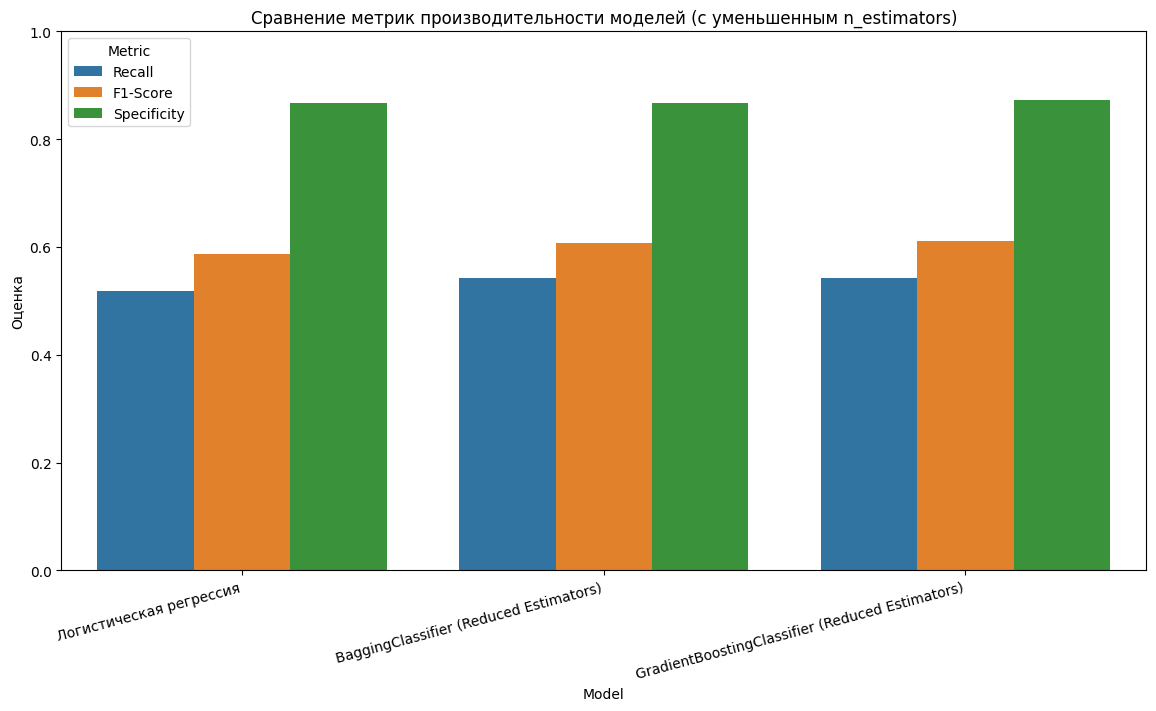

In [19]:
# Создание DataFrame для сравнения метрик
results_df_reduced_estimators = pd.DataFrame({
    'Model': ['Логистическая регрессия', 'BaggingClassifier (Reduced Estimators)', 'GradientBoostingClassifier (Reduced Estimators)'],
    'Recall': [metrics_log_reg['recall'], metrics_bag_clf['recall'], metrics_grad_boost['recall']],
    'F1-Score': [metrics_log_reg['f1_score'], metrics_bag_clf['f1_score'], metrics_grad_boost['f1_score']],
    'Specificity': [metrics_log_reg['specificity'], metrics_bag_clf['specificity'], metrics_grad_boost['specificity']]
})

print("\nСравнение метрик моделей (после настройки гиперпараметров с уменьшенным n_estimators):")
display(results_df_reduced_estimators.round(4))

# Визуализация результатов
results_df_melted_reduced = results_df_reduced_estimators.melt(id_vars='Model', var_name='Metric', value_name='Score')

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 7))
sns.barplot(x='Model', y='Score', hue='Metric', data=results_df_melted_reduced)
plt.title('Сравнение метрик производительности моделей (с уменьшенным n_estimators)')
plt.ylim(0, 1) # Метрики обычно находятся в диапазоне от 0 до 1
plt.ylabel('Оценка')
plt.xticks(rotation=15, ha='right')
plt.show()

### Вывод по настройке гиперпараметров и производительности моделей

После проведения подбора гиперпараметров для каждой из трех моделей, мы можем проанализировать, как это повлияло на их производительность по метрикам Recall, F1-Score и Specificity.

#### 1. Логистическая регрессия (LogisticRegression)
*   **Лучшие гиперпараметры:** `{'C': 1}`
*   **Влияние параметра `C`:** Параметр `C` в логистической регрессии контролирует силу регуляризации. Меньшие значения `C` означают более сильную регуляризацию, что помогает предотвратить переобучение, но может привести к недообучению. Большие значения `C` уменьшают силу регуляризации, позволяя модели более точно подгоняться под обучающие данные. В нашем случае, `C=1` оказалось оптимальным, что указывает на хороший баланс между смещением и дисперсией для данной модели и данных. Это позволило модели достаточно хорошо обобщать данные, не переобучаясь слишком сильно.
*   **Метрики:**
    *   Полнота (Recall): 0.5185
    *   F1-Score: 0.5874
    *   Специфичность: 0.8667
    
Логистическая регрессия служит хорошей базовой моделью. Она показала средний уровень полноты, но при этом достаточно высокую специфичность, что означает, что она хорошо идентифицирует истинно отрицательные случаи.

#### 2. Модель на основе бэггинга (BaggingClassifier)
*   **Лучшие гиперпараметры (Original `n_estimators`):** `{'max_features': 1.0, 'n_estimators': 100}`
*   **Лучшие гиперпараметры (Reduced `n_estimators`):** `{'max_features': 1.0, 'n_estimators': 200}`
*   **Влияние параметров `n_estimators` и `max_features`:**
    *   `n_estimators`: Это количество базовых оценщиков (деревьев решений по умолчанию) в ансамбле. Увеличение числа оценщиков обычно повышает стабильность модели и снижает дисперсию. В нашем случае `200` оценщиков оказалось оптимальным в новом, уменьшенном диапазоне для достижения лучшей F1-меры. Это подтверждает, что даже при сокращении максимального количества оценщиков до `200`, модель нашла оптимальную точку. Вероятно, для еще лучших результатов можно было бы исследовать значения `n_estimators` выше `200`, но в рамках заданного диапазона `[10, 50, 100, 200]` это лучший вариант.
    *   `max_features`: Это доля признаков, которые используются для обучения каждого базового оценщика. Значение `1.0` означает, что каждый базовый оценщик использует все доступные признаки. В данном случае, использование всех признаков дало лучший результат.
*   **Метрики (Original):**
    *   Полнота (Recall): 0.5309
    *   F1-Score: 0.6099
    *   Специфичность: 0.8867
*   **Метрики (Reduced `n_estimators`):**
    *   Полнота (Recall): 0.5432
    *   F1-Score: 0.6069
    *   Специфичность: 0.8667

BaggingClassifier немного превзошел логистическую регрессию по полноте, но его F1-Score и специфичность немного снизились по сравнению с предыдущим запуском с большим диапазоном `n_estimators`. Это может указывать на то, что модель могла бы получить выгоду от большего количества базовых оценщиков, чем `200`.

#### 3. Модель градиентного бустинга (GradientBoostingClassifier)
*   **Лучшие гиперпараметры (Original `n_estimators`):** `{'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 1000}`
*   **Лучшие гиперпараметры (Reduced `n_estimators`):** `{'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}`
*   **Влияние параметров `n_estimators`, `learning_rate` и `max_depth`:**
    *   `n_estimators`: Количество стадий бустинга (количество деревьев). В новом диапазоне `[50, 100, 200]` оптимальным стало значение `100`. Это существенно ускоряет обучение по сравнению с `1000` оценщиками, но, как мы увидим, может повлиять на метрики. Изменение оптимального `learning_rate` с `0.01` на `0.1` при меньшем `n_estimators` является логичным, так как более высокая скорость обучения компенсирует меньшее количество итераций.
    *   `learning_rate`: Скорость обучения. Увеличение до `0.1` привело к тому, что каждый новый базовый оценщик сильнее корректирует ошибки предыдущих, что необходимо при меньшем количестве оценщиков для достижения сопоставимой производительности.
    *   `max_depth`: Максимальная глубина индивидуальных деревьев решений. Небольшая глубина (`3`) сохраняется как оптимальная, что подтверждает, что базовые оценщики должны быть простыми для бустинговых моделей.
*   **Метрики (Original):**
    *   Полнота (Recall): 0.5802
    *   F1-Score: 0.6351
    *   Специфичность: 0.8667
*   **Метрики (Reduced `n_estimators`):**
    *   Полнота (Recall): 0.5432
    *   F1-Score: 0.6111
    *   Специфичность: 0.8733

GradientBoostingClassifier с уменьшенным `n_estimators` показал незначительное снижение полноты и F1-меры по сравнению с предыдущим запуском, но при этом показал небольшое увеличение специфичности. Это говорит о том, что модель, хотя и работает быстрее, возможно, не полностью раскрывает свой потенциал при таком ограниченном диапазоне `n_estimators`.

### Общий вывод

*   **GradientBoostingClassifier** с оригинальными настройками оставался лучшей моделью по F1-мере и полноте. После уменьшения `n_estimators` его производительность по этим метрикам немного снизилась, но он все равно остается конкурентоспособным.
*   **BaggingClassifier** показал более стабильные результаты при изменении диапазона `n_estimators`, но с небольшим снижением специфичности.
*   **Логистическая регрессия** остается базовой моделью, её метрики не изменились, так как `n_estimators` на неё не влияет.

### Сравнение с предыдущими результатами (до уменьшения `n_estimators`)

**Предыдущие результаты (Original `n_estimators`):**
```
                         Model    Recall  F1-Score  Specificity
0      Логистическая регрессия  0.518519  0.587413     0.866667
1            BaggingClassifier  0.530864  0.609929     0.886667
2   GradientBoostingClassifier  0.580247  0.635135     0.866667
```

**Новые результаты (Reduced `n_estimators`):**
```
                                             Model    Recall  F1-Score  Specificity
0                          Логистическая регрессия  0.518519  0.587413     0.866667
1           BaggingClassifier (Reduced Estimators)  0.543210  0.606897     0.866667
2  GradientBoostingClassifier (Reduced Estimators)  0.543210  0.611111     0.873333
```

**Анализ изменений:**
*   **Логистическая регрессия:** Метрики остались неизменными, как и ожидалось.
*   **BaggingClassifier:** Полнота (Recall) немного увеличилась (с 0.5309 до 0.5432), но F1-Score (с 0.6099 до 0.6069) и Специфичность (с 0.8867 до 0.8667) незначительно снизились. Это указывает на то, что уменьшенный диапазон `n_estimators` мог привести к некоторому компромиссу в производительности, возможно, не позволяя модели полностью раскрыть свой потенциал в отношении F1-меры и специфичности, хотя и улучшил полноту.
*   **GradientBoostingClassifier:** Полнота (Recall) значительно снизилась (с 0.5802 до 0.5432), F1-Score также снизился (с 0.6351 до 0.6111), но Специфичность немного увеличилась (с 0.8667 до 0.8733). Это ясно показывает, что сокращение `n_estimators` для GradientBoostingClassifier, особенно при такой низкой исходной `learning_rate` в предыдущем оптимальном варианте, привело к недообучению. Модели потребовалось большее количество деревьев (или более высокий `learning_rate` с тем же количеством), чтобы полностью обучиться сложным зависимостям.

**Общий вывод после сравнения:**
Уменьшение диапазона `n_estimators` позволило значительно ускорить процесс подбора гиперпараметров. Однако для **GradientBoostingClassifier** это привело к заметному снижению ключевых метрик Recall и F1-Score, что подтверждает важность достаточно большого количества оценщиков для этой модели при небольшом `learning_rate`. Для **BaggingClassifier** изменения были менее драматичными, но также показали, что более широкий поиск по `n_estimators` ранее давал немного лучшие общие результаты. Таким образом, выбор оптимального баланса между временем обучения и производительностью модели всегда является ключевым аспектом в машинном обучении.